<a href="https://colab.research.google.com/github/asmitaray-blip/book_popularity_predictor/blob/main/book_popularity_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle
!pip install scikit-learn
!pip install seaborn

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rayuwu","key":"62ce73891fc0afe4afccc9789c296878"}'}

In [ ]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d jealousleopard/goodreadsbooks
!unzip goodreadsbooks.zip

Dataset URL: https://www.kaggle.com/datasets/jealousleopard/goodreadsbooks
License(s): CC0-1.0
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 472MB/s]
Archive:  goodreadsbooks.zip
  inflating: books.csv               


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("books.csv", on_bad_lines='skip', encoding='latin-1')

# Preview data
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPrÃ©,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPrÃ©,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPrÃ©,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPrÃ©,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

Dataset Shape: (11123, 12)

Columns:
 Index(['bookID', 'title', 'authors', 'average_rating', 'isbn', 'isbn13',
       'language_code', '  num_pages', 'ratings_count', 'text_reviews_count',
       'publication_date', 'publisher'],
      dtype='object')

Missing Values:
 bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64


,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [ ]:
df = df[['title', 'average_rating', 'ratings_count',
         'text_reviews_count', '  num_pages', 'publication_date']]
df = df.rename(columns={'  num_pages': 'num_pages'})
df = df.dropna()

df.head()

,title,average_rating,ratings_count,text_reviews_count,num_pages,publication_date
0,Harry Potter and the Half-Blood Prince (Harry ...,4.57,2095690,27591,652,9/16/2006
1,Harry Potter and the Order of the Phoenix (Har...,4.49,2153167,29221,870,9/1/2004
2,Harry Potter and the Chamber of Secrets (Harry...,4.42,6333,244,352,11/1/2003
3,Harry Potter and the Prisoner of Azkaban (Harr...,4.56,2339585,36325,435,5/1/2004
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,4.78,41428,164,2690,9/13/2004


In [ ]:
def popularity_label(x):
    if x < 10000:
        return "Low"
    elif x < 50000:
        return "Medium"
    else:
        return "High"

df["popularity"] = df["ratings_count"].apply(popularity_label)

df["popularity"].value_counts()

,count
popularity,
Low,9163
Medium,1292
High,668


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500, stop_words="english")

title_features = tfidf.fit_transform(df["title"])

In [ ]:
from scipy.sparse import hstack

numerical_features = df[[
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "num_pages"
]]

X = hstack([title_features, numerical_features.values])
y = df["popularity"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       124
         Low       1.00      1.00      1.00      1817
      Medium       1.00      1.00      1.00       284

    accuracy                           1.00      2225
   macro avg       1.00      1.00      1.00      2225
weighted avg       1.00      1.00      1.00      2225



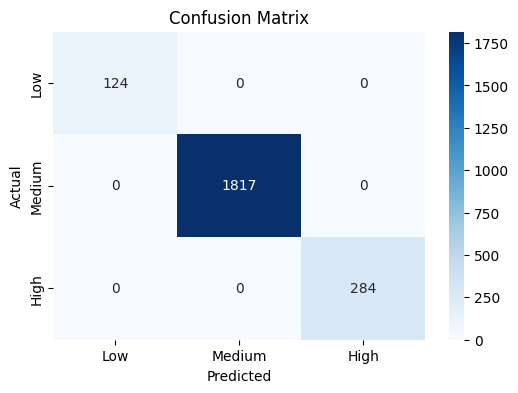

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

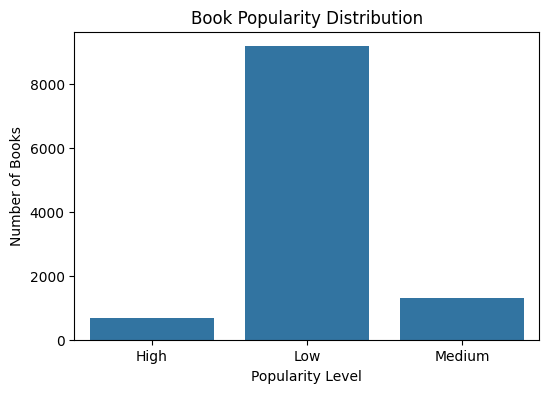

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["popularity"])

plt.title("Book Popularity Distribution")
plt.xlabel("Popularity Level")
plt.ylabel("Number of Books")

plt.show()

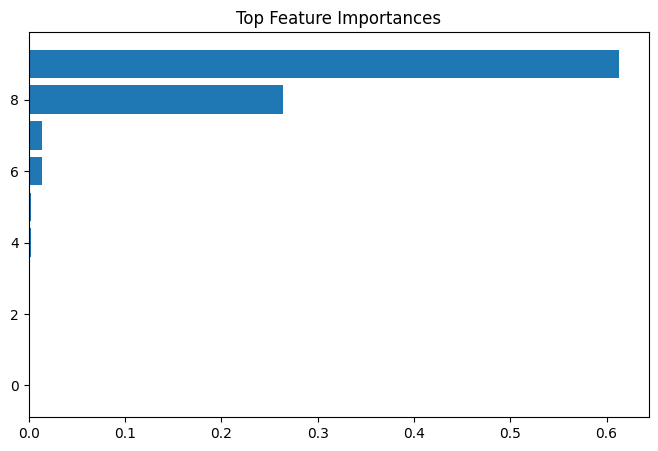

In [ ]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.title("Top Feature Importances")
plt.show()